In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving LinearRegression-Prac-Dataset2.csv to LinearRegression-Prac-Dataset2.csv


In [3]:
#Read exel file
df = pd.read_csv('LinearRegression-Prac-Dataset2.csv')
# Display first  rows
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
df.shape

(414, 8)

In [5]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [7]:
df.duplicated().any()

np.False_

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#check missing values
df.isnull().any()

,0
No,False
X1 transaction date,False
X2 house age,False
X3 distance to the nearest MRT station,False
X4 number of convenience stores,False
X5 latitude,False
X6 longitude,False
Y house price of unit area,False


In [10]:
Numerical_columns = df.select_dtypes(include="number").columns.to_list()
print(Numerical_columns)

['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']


In [11]:
Categorical_columns = df.select_dtypes(exclude="number").columns.to_list()
print(Categorical_columns)

[]


In [12]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [13]:
Categorical_columns = df.select_dtypes(exclude="number").columns
print(Categorical_columns)

Index([], dtype='object')


In [14]:
Categorical_columns = df.select_dtypes(exclude="number").columns.to_list()
print(Categorical_columns)

[]


In [15]:
# Statistical Measure of Numeric Columns
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [19]:
# Check the value count of categories
df['X2 house age'].value_counts()

,count
X2 house age,
0.0,17
13.6,7
13.3,6
16.2,6
13.2,6
...,...
26.8,1
7.6,1
1.9,1


In [21]:
# Check the value count of categories
df[ 'X1 transaction date'].value_counts()

,count
X1 transaction date,
2013.417,58
2013.500,47
2013.083,46
2012.917,38
2013.250,32
2012.833,31
2012.667,30
2013.333,29
2013.000,28


In [22]:
# Check the value count of categories
df['X4 number of convenience stores'].value_counts()

,count
X4 number of convenience stores,
5,67
0,67
3,46
1,46
6,37
7,31
4,31
8,30
9,25


In [23]:
for col in Categorical_columns:
    print(df[col].value_counts())
    print("")
    print(".....")

In [24]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


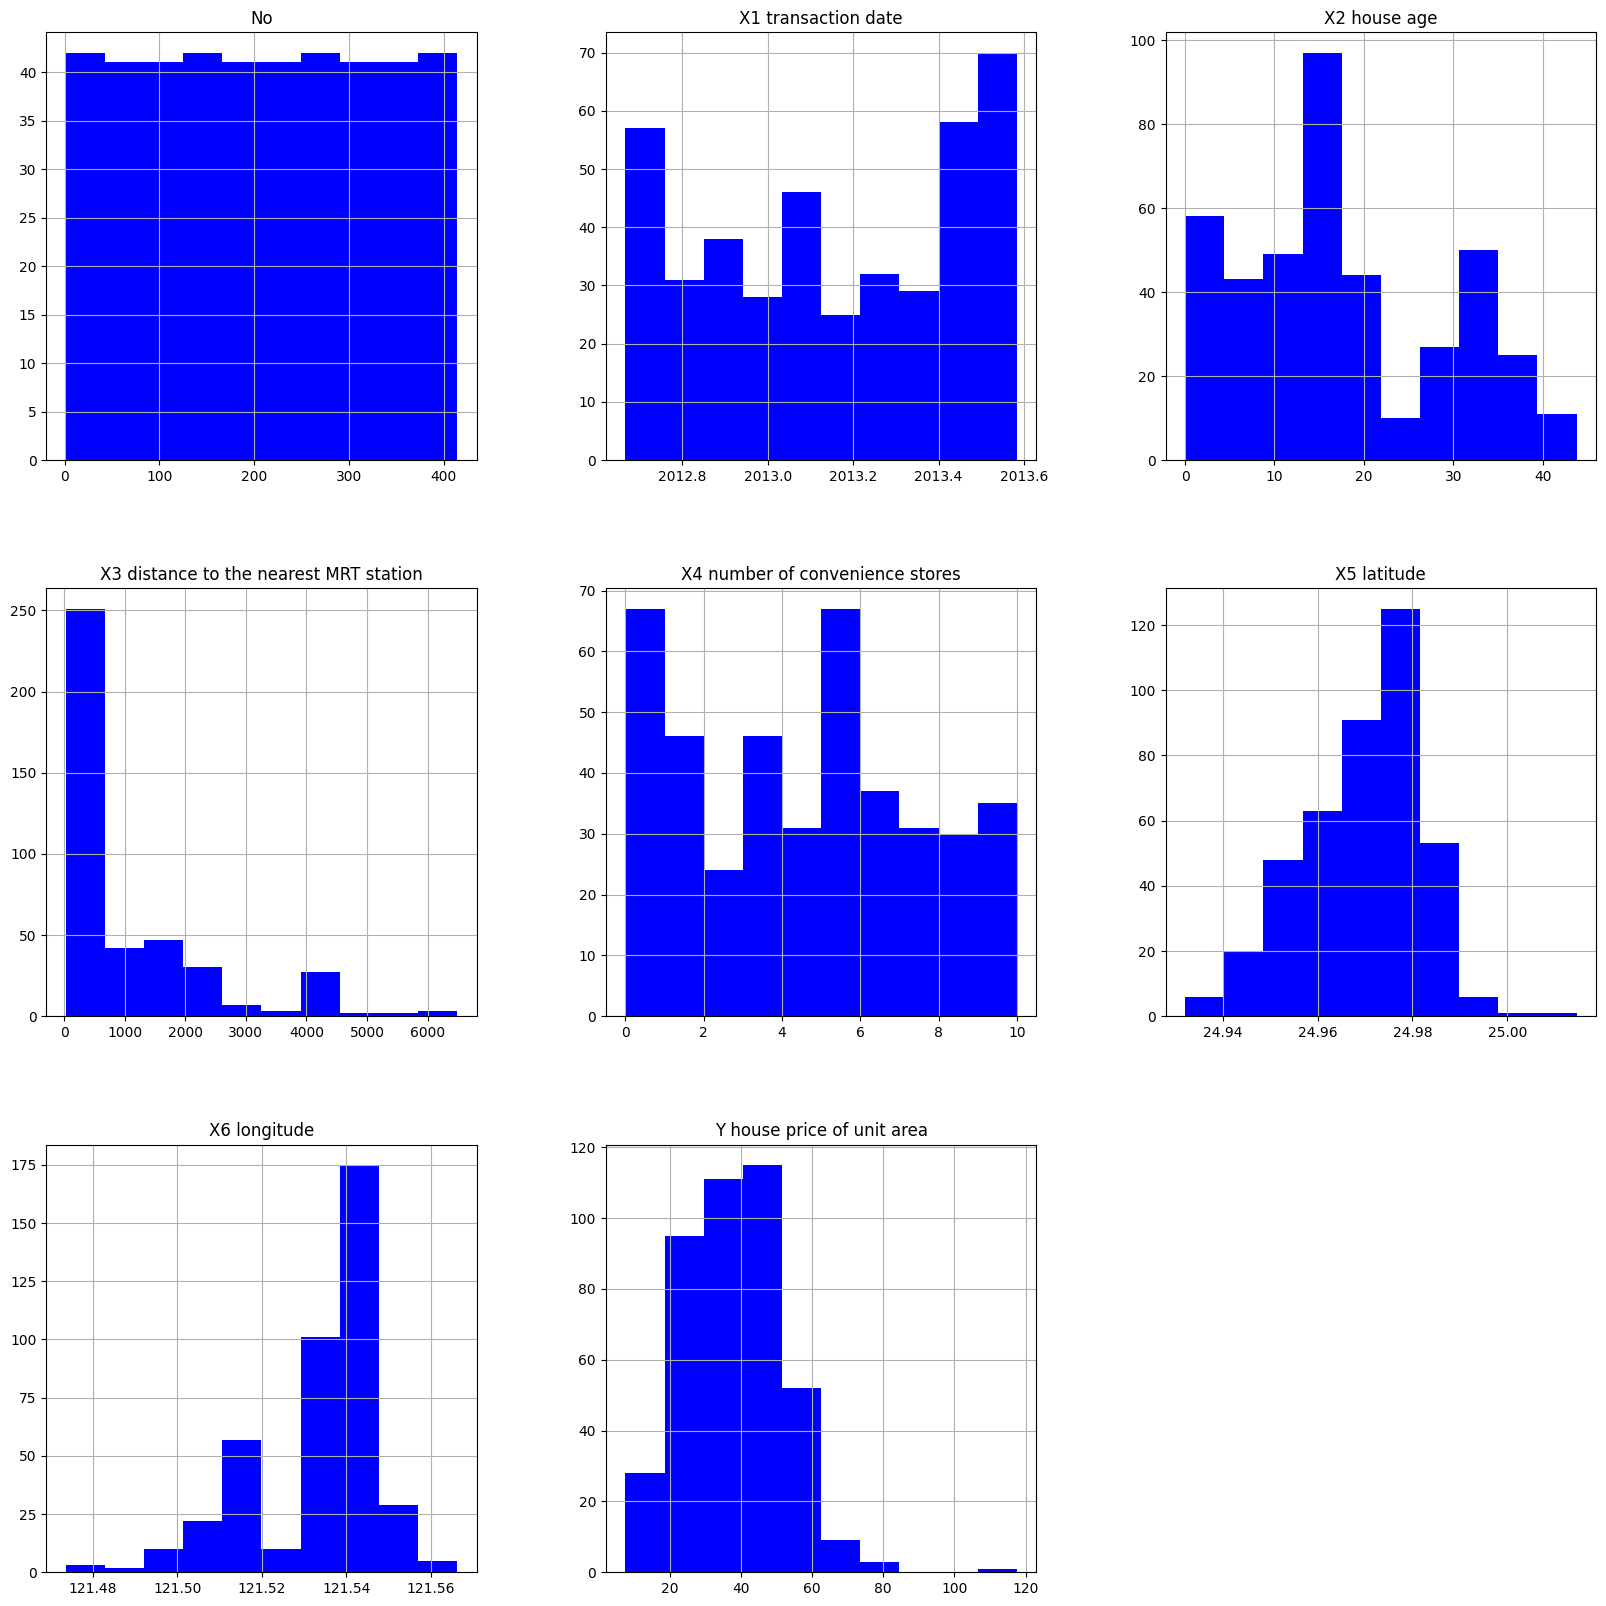

In [25]:
# Histogram:
df.hist(figsize=(20,20), color='blue')
plt.show()

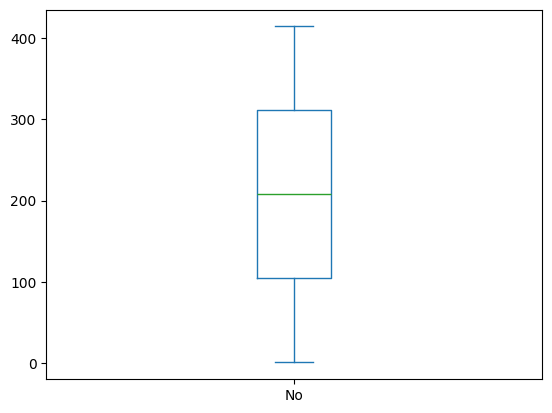

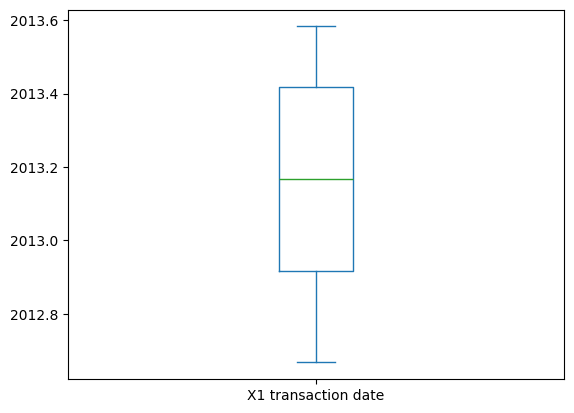

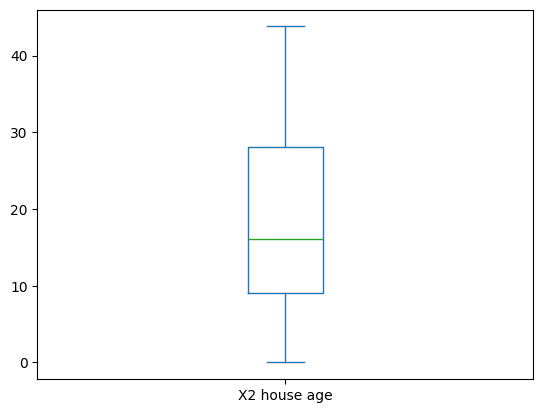

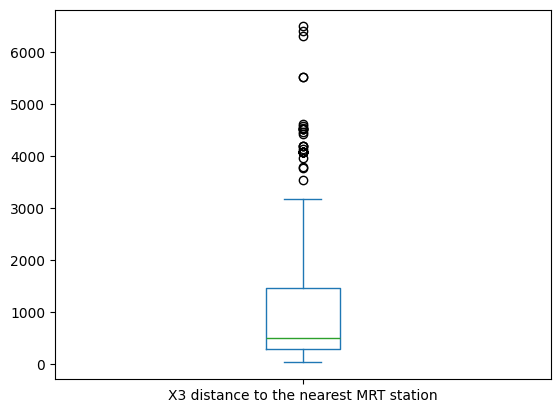

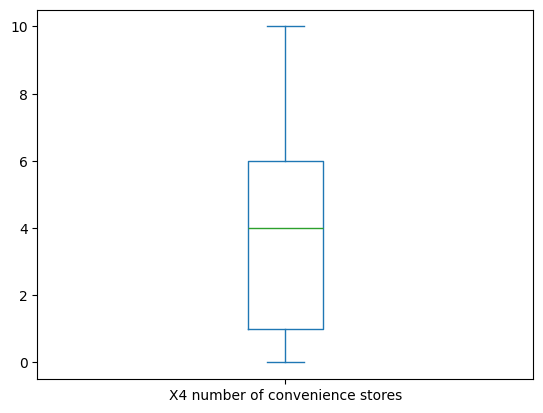

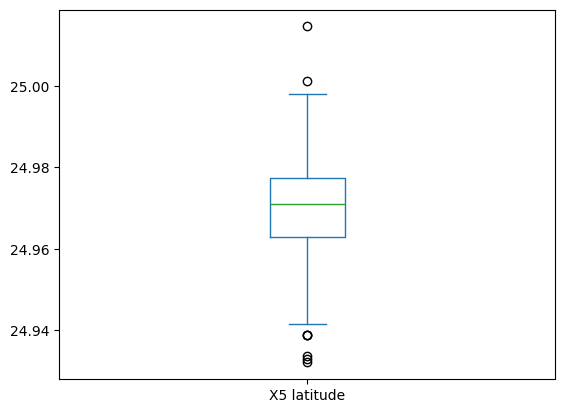

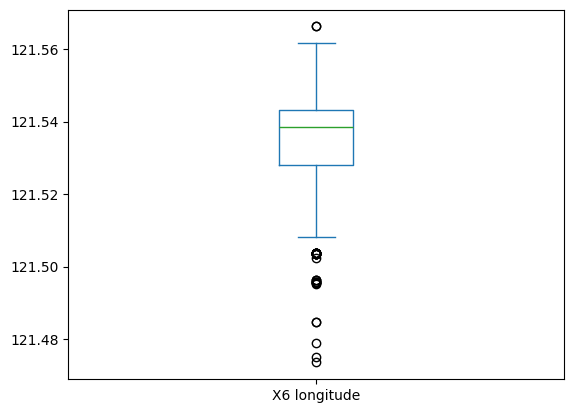

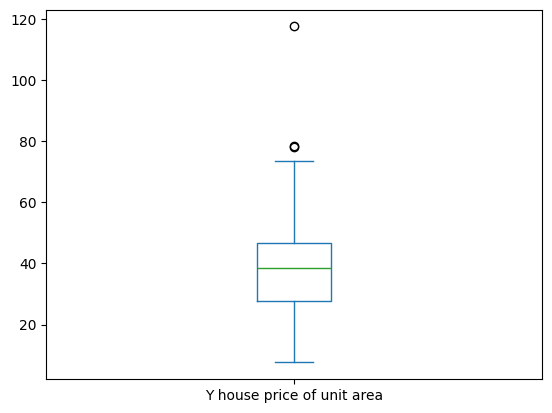

In [26]:
# BoxPlot:
for col in Numerical_columns:
    df[col].plot(kind='box')
    plt.show()

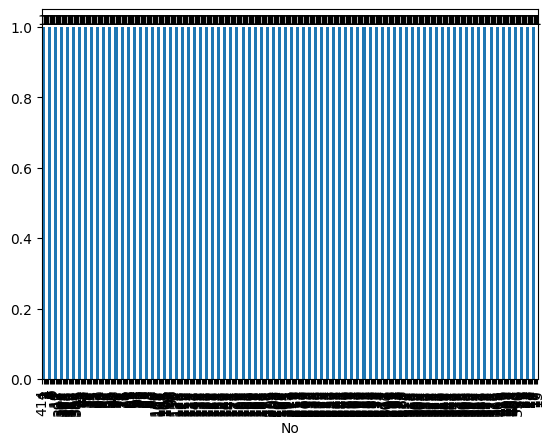

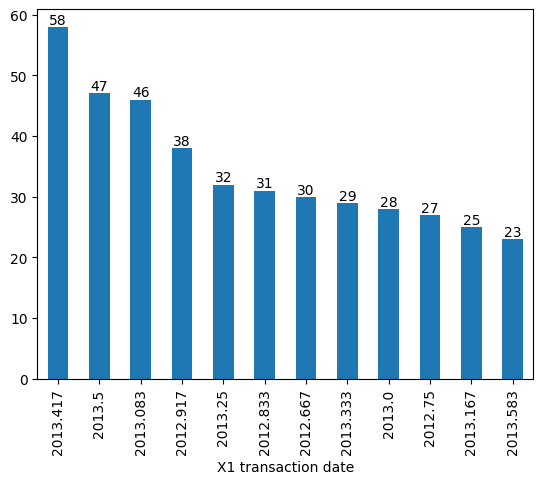

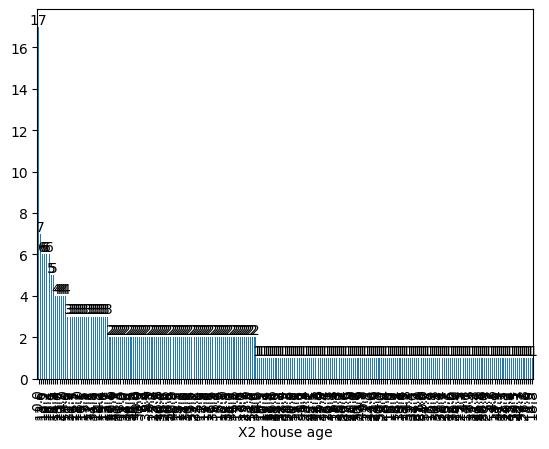

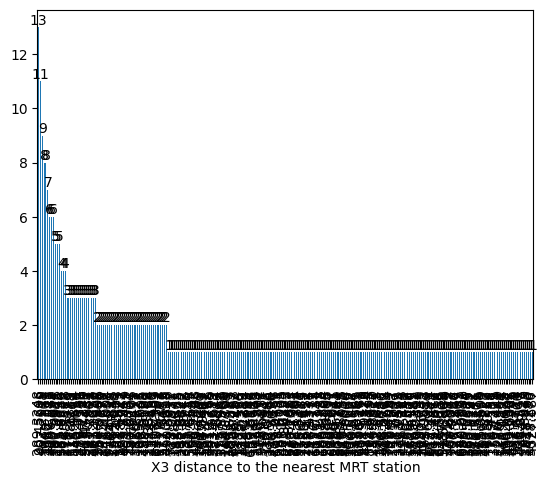

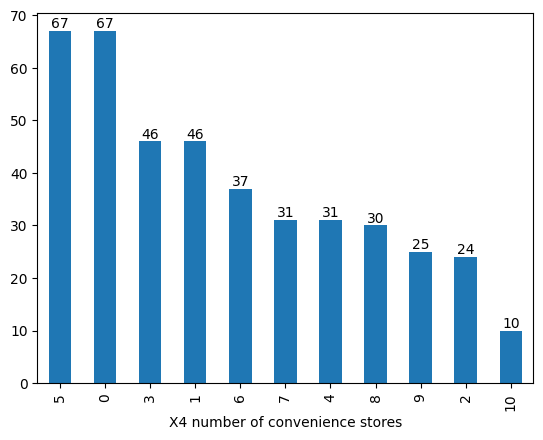

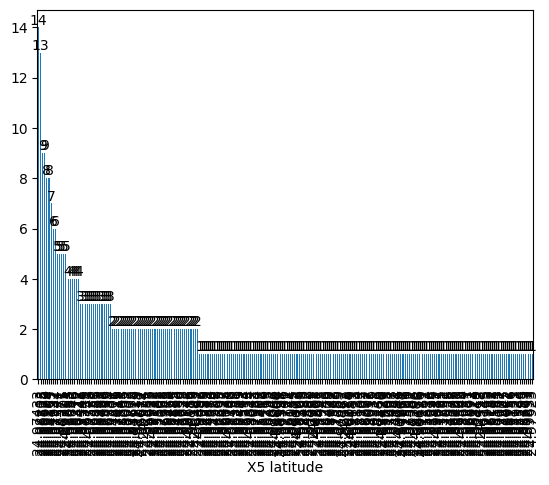

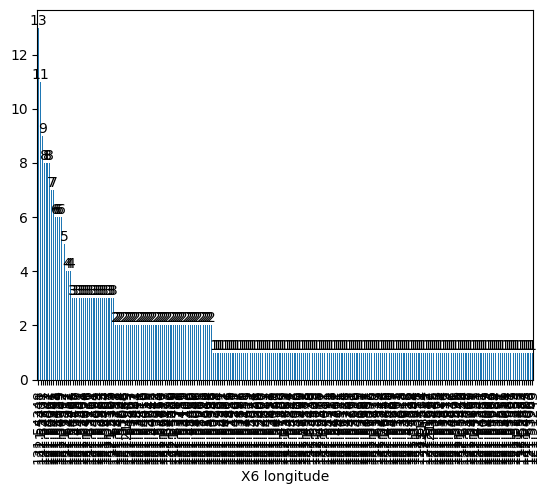

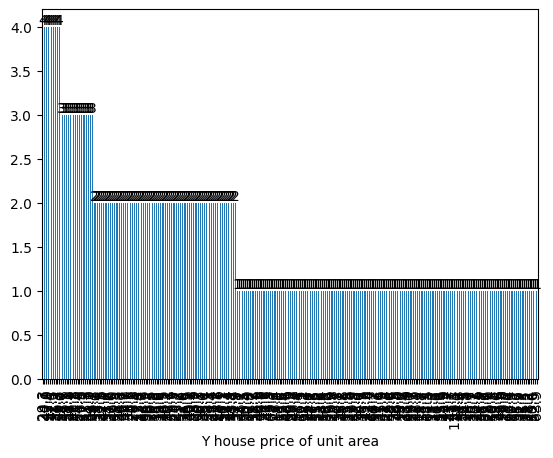

In [29]:
# Bar Chart
for col in Numerical_columns:
    ax = df[col].value_counts().plot(kind = 'bar')
    for i in ax.containers:
        ax.bar_label(i)
    plt.show()

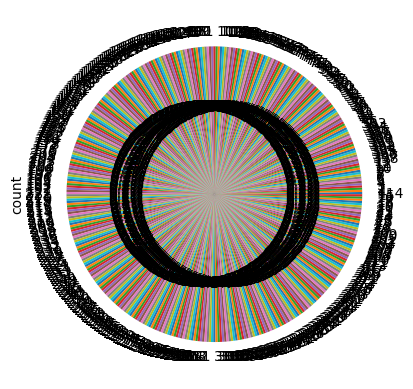

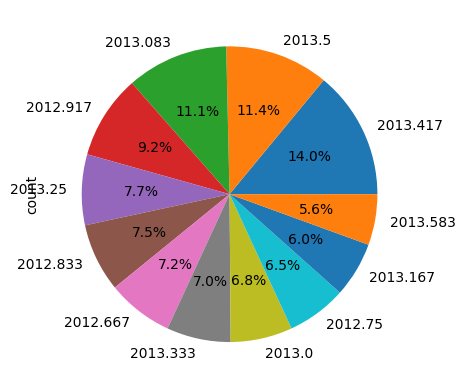

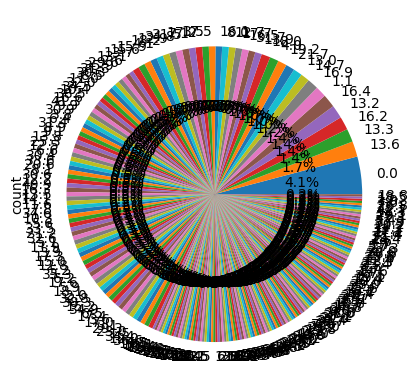

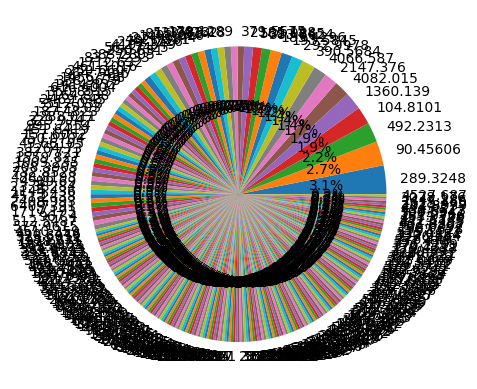

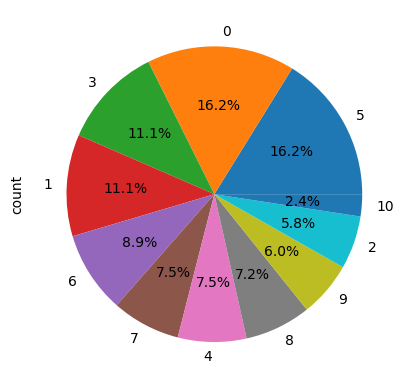

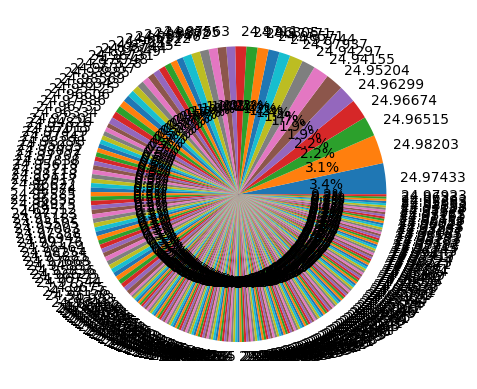

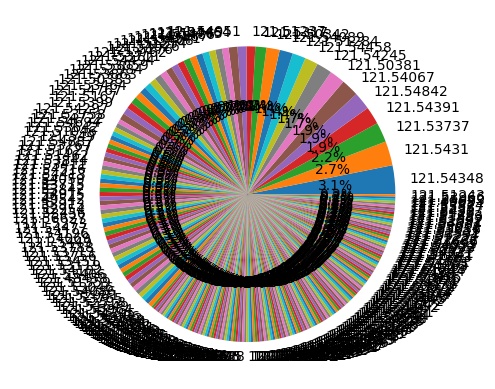

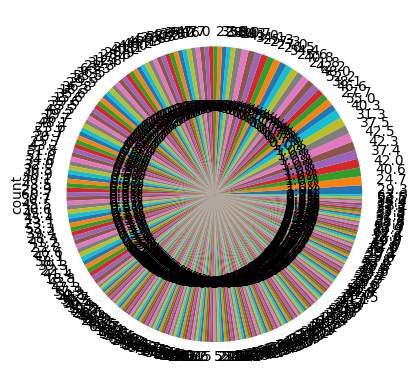

In [30]:
# Pie Plot

for col in Numerical_columns:
  df[col].value_counts().plot(kind = 'pie', autopct= '%1.1f%%')
  plt.show()

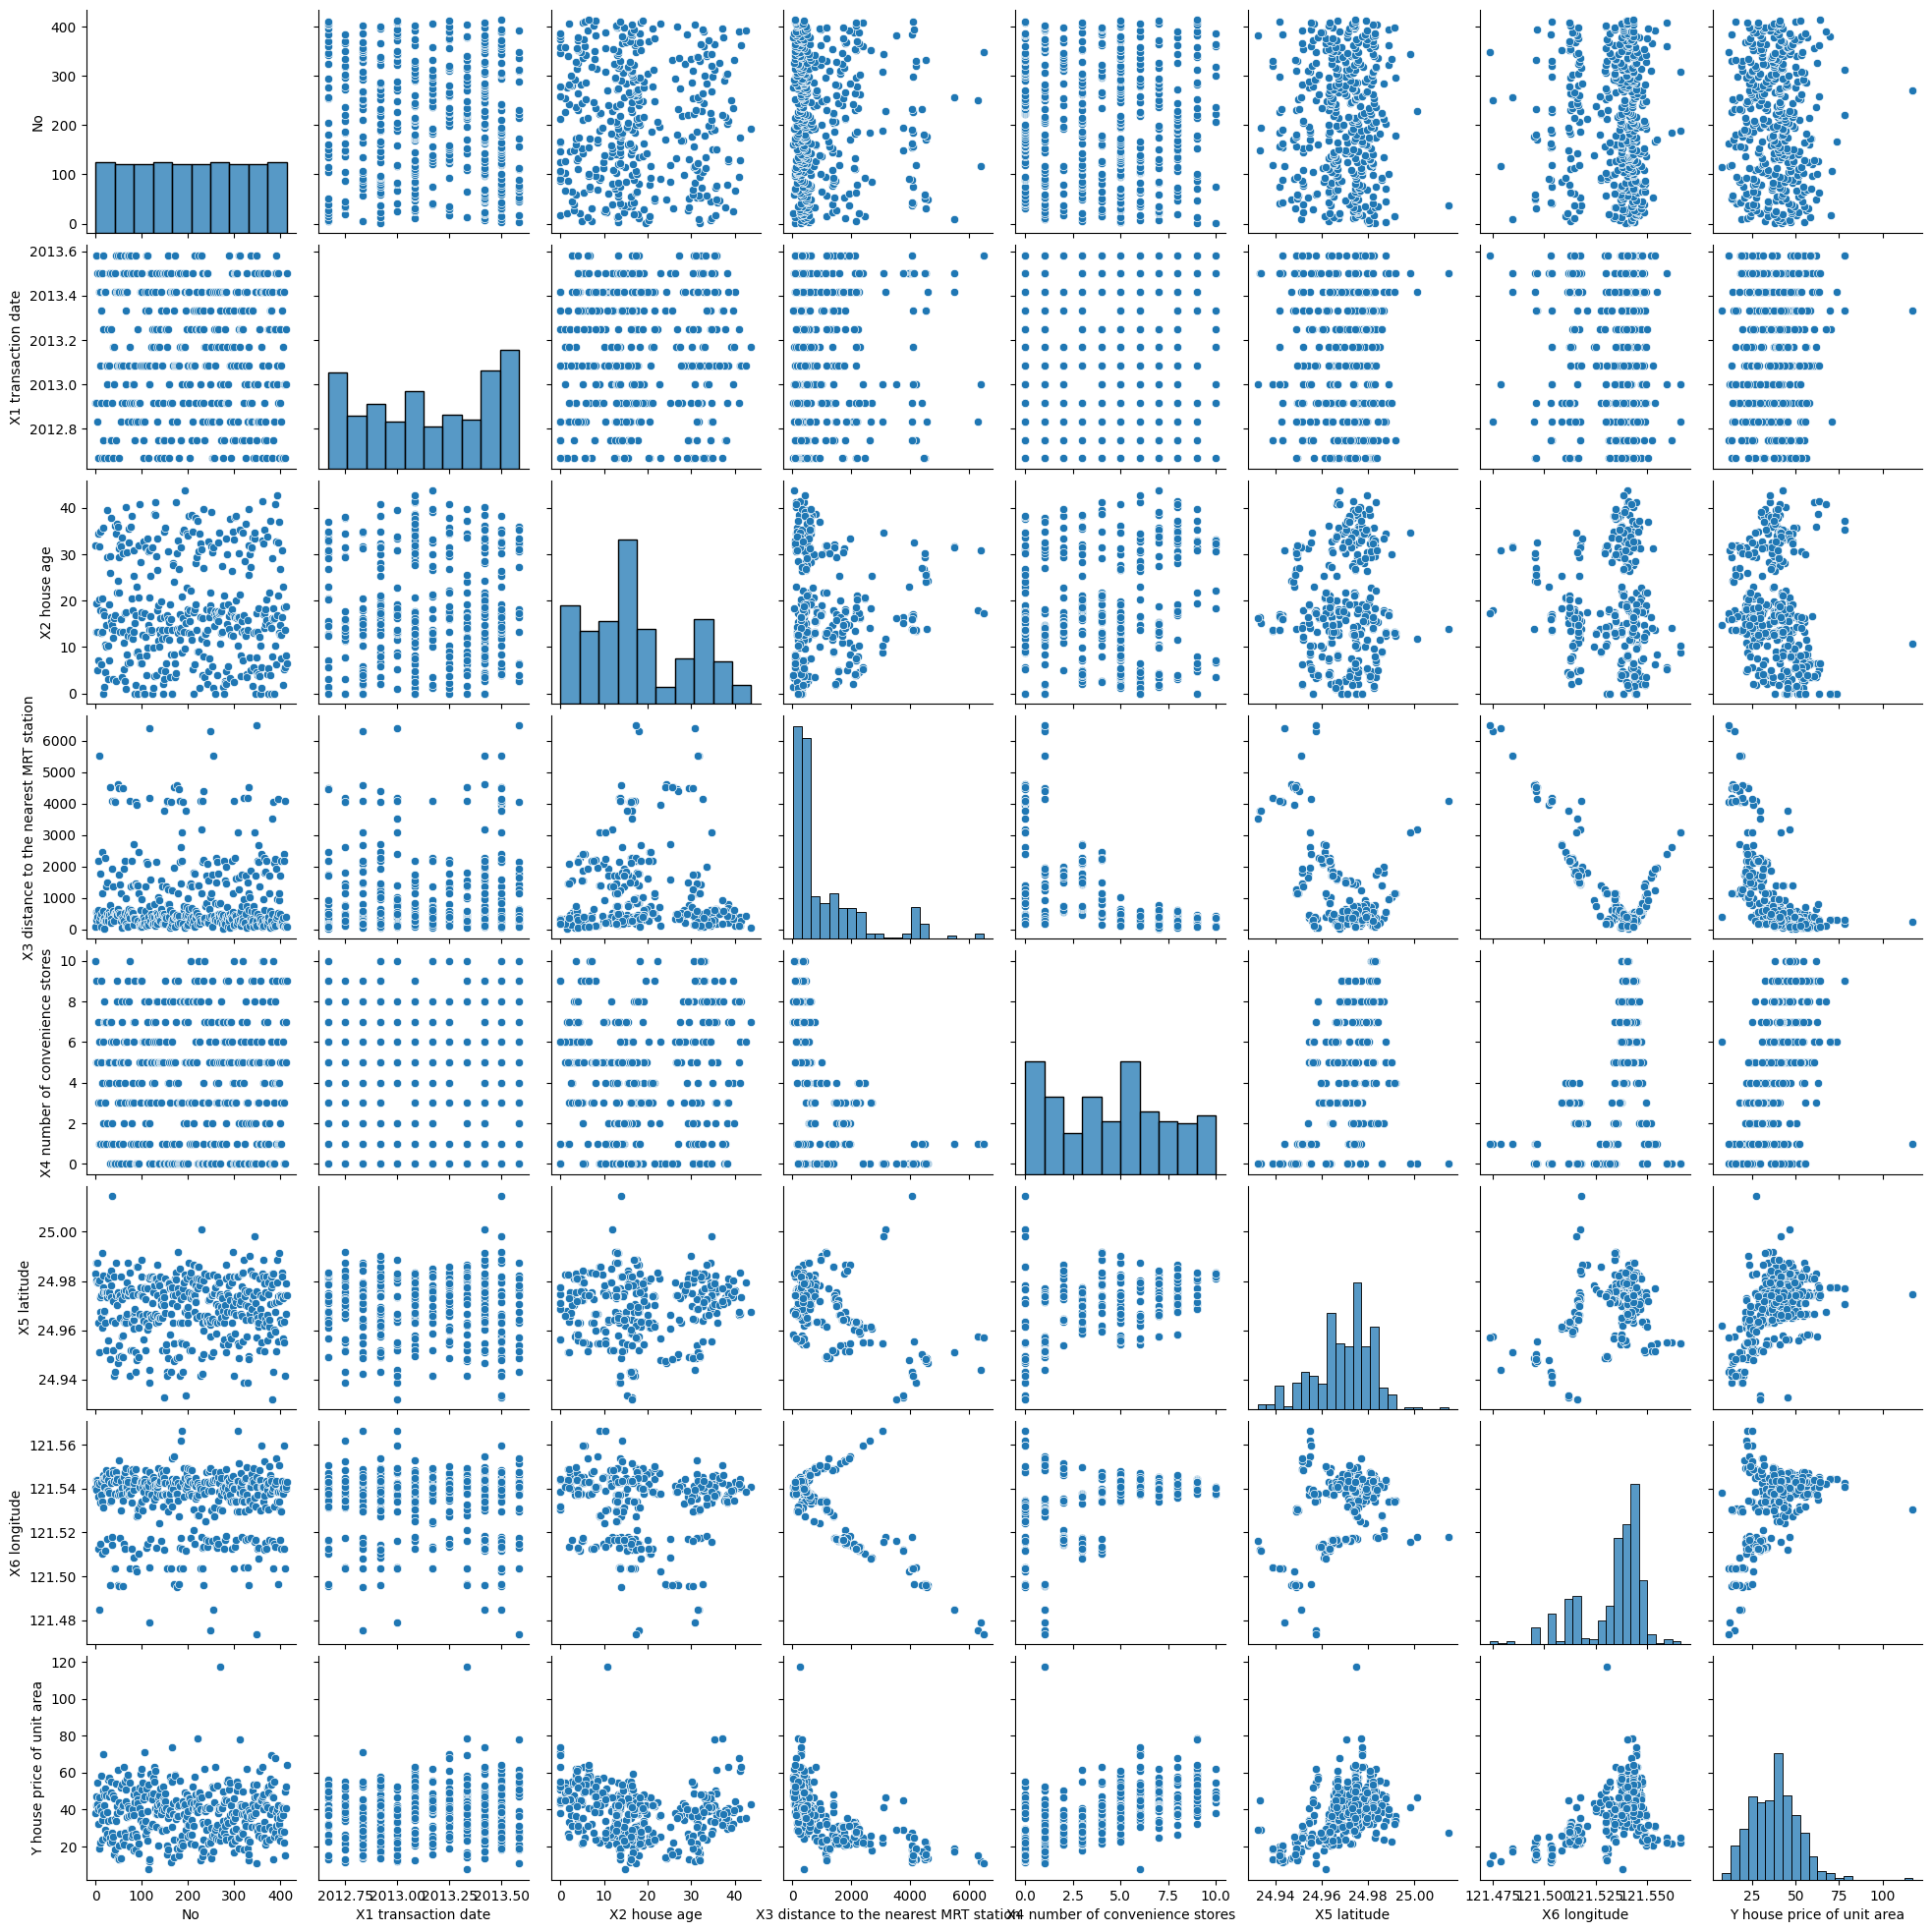

In [32]:
#pairplot
sns.pairplot(df)
plt.show()

In [33]:
# Correlation Matrix
corr_data = df[['No', 'X1 transaction date', 'X2 house age']].corr()
corr_data

,No,X1 transaction date,X2 house age
No,1.000000,-0.048658,-0.032808
X1 transaction date,-0.048658,1.000000,0.017549
X2 house age,-0.032808,0.017549,1.000000


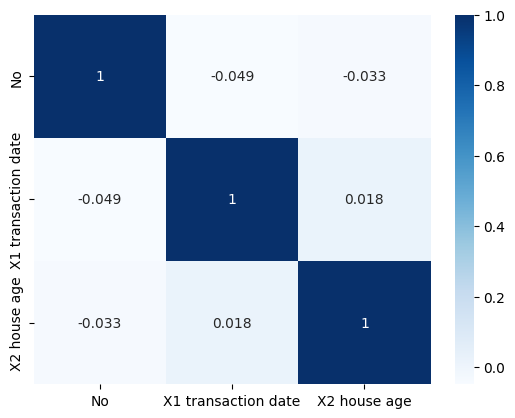

In [34]:
sns.heatmap(corr_data, annot=True, cmap='Blues')
plt.show()

In [35]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [43]:
# Label encoding categorical columns
df['No'] = le.fit_transform(df['No'])

In [38]:
# Label encoding categorical columns
df['X1 transaction date'] = le.fit_transform(df['X1 transaction date'])

In [44]:
# Label encoding categorical columns
df['X2 house age'] = le.fit_transform(df['X2 house age'])

In [41]:
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,3,184,84.87882,10,24.98298,121.54024,37.9
1,2,3,133,306.59470,9,24.98034,121.53951,42.2
2,3,11,81,561.98450,5,24.98746,121.54391,47.3
3,4,10,81,561.98450,5,24.98746,121.54391,54.8
4,5,2,29,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,4,84,4082.01500,0,24.94155,121.50381,15.4
410,411,0,34,90.45606,9,24.97433,121.54310,50.0
411,412,7,128,390.96960,7,24.97923,121.53986,40.6
412,413,4,48,104.81010,5,24.96674,121.54067,52.5


In [ ]:
#Objective:
#To build and evaluate a Linear Regression model that predicts  house price of unit area

In [47]:
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [45]:
# Define features (X) and target (y)
X = df.drop("Y house price of unit area", axis=1)
y = df["Y house price of unit area"]

In [46]:
#  Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)


Training Set Size: (331, 7)
Testing Set Size: (83, 7)


In [48]:
#  Model Training
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


In [49]:
# Step 6: Model Coefficients "General linear equation: Y=β0+β1X1+β2X2+β3X3+...+βnXn+ε "
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print("\nModel Coefficients:")
print(coeff_df)
print("Intercept:", model.intercept_)


Model Coefficients:
                                        Coefficient
No                                        -0.005485
X1 transaction date                        0.459433
X2 house age                              -0.047741
X3 distance to the nearest MRT station    -0.004772
X4 number of convenience stores            1.072969
X5 latitude                              227.367218
X6 longitude                             -30.976979
Intercept: -1870.0903732749814


In [50]:
# Step : 7 Predictions
y_pred = model.predict(X_test)

In [51]:
# Step 8: Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

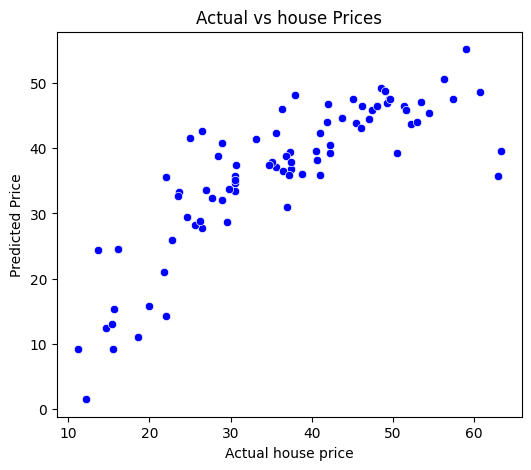

In [52]:
# Step 9: Visualization

# Actual vs Predicted Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred, color="blue")
plt.xlabel("Actual house price")
plt.ylabel("Predicted Price")
plt.title("Actual vs house Prices")
# Save the graph
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

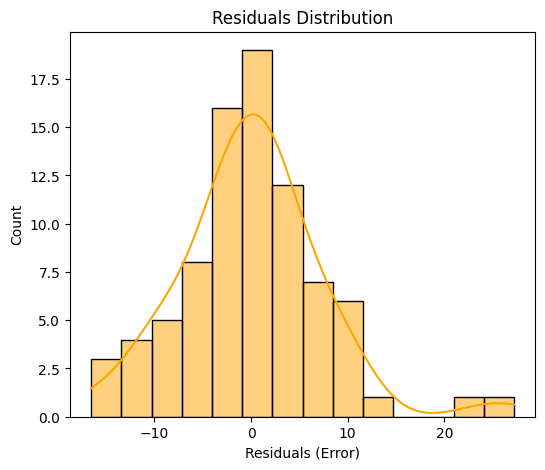

In [53]:
# Residual Plot
plt.figure(figsize=(6, 5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='orange')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (Error)")

# Save the plot
plt.savefig("residuals_distribution.png", dpi=300, bbox_inches='tight')

plt.show()